<a href="https://colab.research.google.com/github/Komakulakavya/SW_PVS_RDH/blob/main/majorrr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BASE PAPER  CORRECTED APPROACH


=== EMBEDDING on kodim04.png ===
Valid embedding opportunities (pairs) : 120932
Payload bits (W)                     : 104016
Total embedded bits (Q+L+W)          : 120932
Embedded image saved as Emb_img.tiff
Embedding PSNR : 41.49 dB

=== EXTRACTION from Emb_img.tiff ===
Extracted total bits (B1) : 120932
Payload bits (W)         : 104016
Extraction PSNR : inf dB


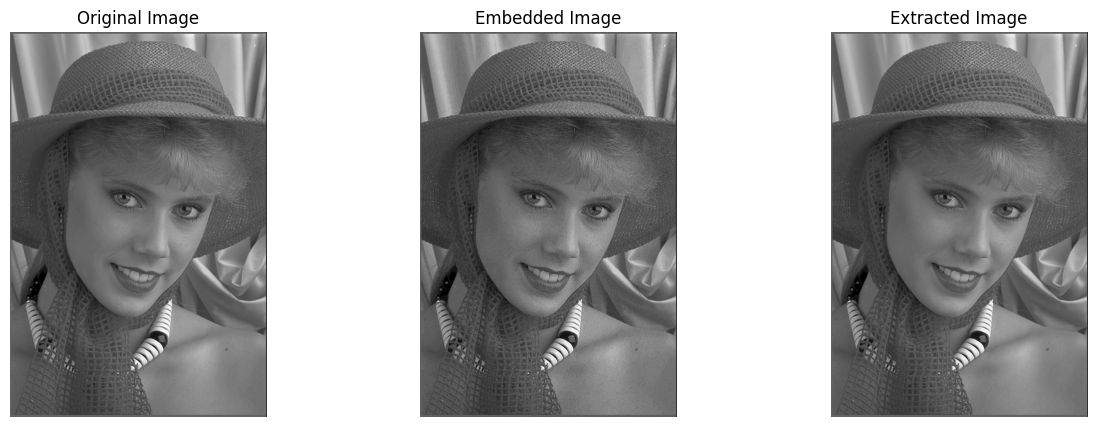

In [ ]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
from PIL import Image as PILImage
import math

def bin16(x): return ''.join(str((x >> i) & 1) for i in range(15, -1, -1))
def bin10(x): return ''.join(str((x >> i) & 1) for i in range(9, -1, -1))

def emb(Image):
    m, n = Image.shape
    p  = np.zeros((m, n), dtype=np.int16)
    p1 = np.zeros((m, n), dtype=np.int16)


    for i in range(m):
        for j in range(n):
            a = Image[i, j]
            p[i, j]  = a // 10
            p1[i, j] = a %  10


    cnt = sum(1 for i in range(m) for j in range(0, n, 2) if p[i, j] > 1 and p[i, j] == p[i, j + 1])
    print(f"Valid embedding opportunities (pairs) : {cnt}")


    R = [(i, j + 1) for i in range(m) for j in range(0, n, 2) if p[i, j] > 1 and p[i, j + 1] == 0]


    flat_R = [item for pair in R for item in pair]
    loc_map_bin = [bin10(coord) for coord in flat_R]
    loc_bits = ''.join(loc_map_bin)
    L = [int(bit) for bit in loc_bits] if loc_bits else []


    Q1 = bin16(len(L))
    Q = [int(bit) for bit in Q1]


    aux_len = len(Q) + len(L)
    payload_len = cnt - aux_len
    if payload_len < 0:
        print("Warning: Insufficient capacity; setting W empty")
        W = []
    else:
        W = list(np.random.randint(2, size=payload_len))
    print(f"Payload bits (W)                     : {len(W)}")
    print(f"Total embedded bits (Q+L+W)          : {len(Q) + len(L) + len(W)}")

    B1 = Q + L + W

    K1, K2, AR = 4, 6, 5


    shifted_count = 0
    for i in range(m):
        for j in range(0, n, 2):
            if p[i, j] > 1 and p[i, j] - p[i, j + 1] >= 1 and p[i, j + 1] >= 1:
                p[i, j + 1] -= 1
                if p1[i, j + 1] <= AR:
                    p1[i, j + 1] += K1
                else:
                    p1[i, j + 1] -= K2
                shifted_count += 1


    bit = 0
    for i in range(m):
        for j in range(0, n, 2):
            if p[i, j] > 1 and p[i, j] == p[i, j + 1]:
                if bit < len(B1) and B1[bit] == 1:
                    p[i, j + 1] -= 1
                    if p1[i, j + 1] <= AR:
                        p1[i, j + 1] += K1
                    else:
                        p1[i, j + 1] -= K2
                bit += 1


    emb_img = (p * 10 + p1).astype(np.uint8)
    cv2.imwrite("Emb_img.tiff", emb_img)
    print("Embedded image saved as Emb_img.tiff")
    return emb_img, B1

def ext(Image):
    m, n = Image.shape
    p  = np.zeros((m, n), dtype=np.int16)
    p1 = np.zeros((m, n), dtype=np.int16)
    D_p1 = np.zeros((m, n), dtype=np.int16)


    for i in range(m):
        for j in range(n):
            a = Image[i, j]
            p[i, j]  = a // 10
            p1[i, j] = a %  10

    K1, K2, AR = 4, 6, 5
    B1 = []


    for i in range(m):
        for j in range(0, n, 2):
            if p[i, j] <= 1:
                continue
            x = p[i, j]
            y = p[i, j + 1]
            diff = x - y
            if diff == 1:
                B1.append(1)
                p[i, j + 1] += 1
                if p1[i, j + 1] >= K1:
                    p1[i, j + 1] -= K1
                else:
                    p1[i, j + 1] += K2
            elif diff == 0:
                B1.append(0)
            elif diff >= 2:
                p[i, j + 1] += 1
                if y == 0:
                    D_p1[i, j + 1] = p1[i, j + 1]
                if p1[i, j + 1] >= K1:
                    p1[i, j + 1] -= K1
                else:
                    p1[i, j + 1] += K2

    print(f"Extracted total bits (B1) : {len(B1)}")


    Size_Q = 16
    Q_temp = B1[:Size_Q]
    Q_temp_str = ''.join(str(i) for i in Q_temp)
    l_size = int(Q_temp_str, 2) if Q_temp_str else 0


    L = []
    if l_size > 0:
        End_Index_loc = Size_Q + l_size
        if End_Index_loc > len(B1):
            End_Index_loc = len(B1)
        L_temp = B1[Size_Q:End_Index_loc]
        L_temp1 = ''.join(str(i) for i in L_temp)
        L_temp1 = L_temp1[: (len(L_temp1) // 10) * 10]
        L = [int(L_temp1[k: k + 10], 2) for k in range(0, len(L_temp1), 10)]


    payload_len = len(B1) - (16 + l_size)
    print(f"Payload bits (W)         : {payload_len}")


    r = 0
    while r < len(L) - 1:
        row = L[r]
        col = L[r + 1]
        if 0 <= row < m and 0 <= col < n:
            p[row, col] = 0
            p1[row, col] = D_p1[row, col]
        r += 2


    img = np.clip(p * 10 + p1, 0, 255).astype(np.uint8)
    return img, len(B1)

if __name__ == "__main__":

    image_path =['kodim04.png']
    for image in image_path:


      print(f"\n=== EMBEDDING on {image} ===")
      original = cv2.imread(image, 0)
      if original is None:
          print("Error: Original image not loaded. Check the file path!")
          exit()

      emb_img, B1_embedded = emb(original)


      mse = np.mean((original - emb_img) ** 2)
      psnr_emb = float('inf') if mse == 0 else 20 * math.log10(255 / math.sqrt(mse))
      print(f"Embedding PSNR : {psnr_emb:.2f} dB")


      print(f"\n=== EXTRACTION from Emb_img.tiff ===")
      if not os.path.exists("Emb_img.tiff"):
          print("Error: Embedded image file not found!")
          exit()
      emb_loaded = cv2.imread("Emb_img.tiff", 0)
      recovered, b1_length = ext(emb_loaded)


      cv2.imwrite('reversible.tiff', recovered)


      mse = np.mean((original - recovered) ** 2)
      psnr_ext = float('inf') if mse == 0 else 20 * math.log10(255 / math.sqrt(mse))
      print(f"Extraction PSNR : {'inf' if math.isinf(psnr_ext) else f'{psnr_ext:.2f}'} dB")


      plt.figure(figsize=(15, 5))
      plt.subplot(1, 3, 1)
      plt.imshow(original, cmap='gray')
      plt.title('Original Image')
      plt.axis('off')

      plt.subplot(1, 3, 2)
      plt.imshow(emb_img, cmap='gray')
      plt.title('Embedded Image')
      plt.axis('off')

      plt.subplot(1, 3, 3)
      plt.imshow(recovered, cmap='gray')
      plt.title('Extracted Image')
      plt.axis('off')

      plt.show()

## **Sliding window approach **

🎯 PERFECT SLIDING WINDOW FINAL
Guaranteed perfect reconstruction with exact loop symmetry
4.1.01.tiff

=== EMBEDDING ===
Embeddable pairs: 30761
Payload capacity: 29833
Total embedded bits: 30761
Embedded 30761 bits using 30761 pairs
Embedded image saved as Emb_img.tiff
MSE EMBEDDING 7.1795654296875
Embedding PSNR: 39.57 dB

=== EXTRACTION ===
Extracted total bits (B1): 30761
Payload bits (W): 29833
Extraction PSNR: inf dB

=== FINAL RESULTS ===
comparision [[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 ...
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]]

Capacity: 30761 bits (46.94%)
Accuracy: 100.000000%
embedding [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 

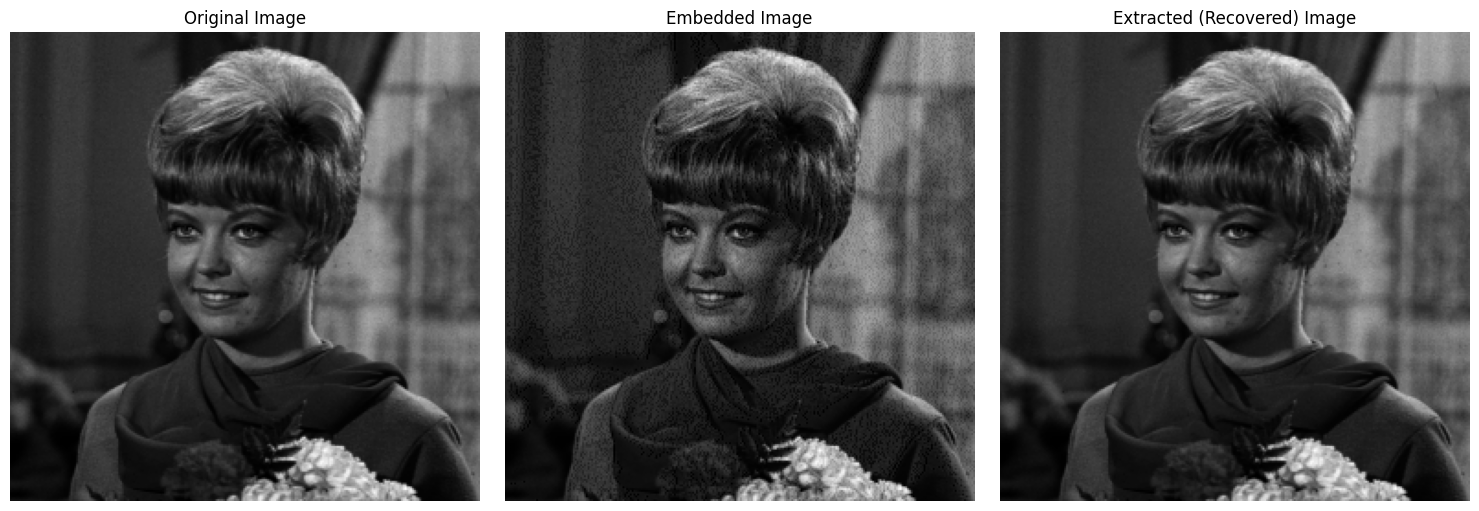

In [ ]:
from matplotlib import pyplot as plt

"""
PERFECT SLIDING WINDOW FINAL: Guaranteed perfect reconstruction
Key insight: Use EXACT same loop order for embedding and extraction
"""

import cv2
import numpy as np
import math

def bin16(x): return ''.join(str((x >> i) & 1) for i in range(15, -1, -1))
def bin10(x): return ''.join(str((x >> i) & 1) for i in range(9, -1, -1))

def emb(Image):
    m, n = Image.shape
    p = np.zeros((m, n), dtype=np.int16)
    p1 = np.zeros((m, n), dtype=np.int16)
    p_original = np.zeros((m, n), dtype=np.int16)
    p1_original = np.zeros((m, n), dtype=np.int16)

    for i in range(m):
        for j in range(n):
            a = Image[i, j]
            p[i, j] = a // 10
            p1[i, j] = a % 10
            p_original[i, j] = a // 10
            p1_original[i, j] = a % 10

    R_positions = []
    for i in range(m):
        for j in range(n - 1):
            if p[i, j] > 1 and p[i, j + 1] == 0:
                R_positions.append((i, j + 1, p1_original[i, j + 1]))


    flat_R = []
    for r_data in R_positions:
        flat_R.extend([r_data[0], r_data[1], r_data[2]])

    loc_map_bin = []
    for k in range(0, len(flat_R), 3):
        if k + 2 < len(flat_R):
            row, col, orig_p1 = flat_R[k], flat_R[k+1], flat_R[k+2]
            loc_map_bin.append(bin10(row))
            loc_map_bin.append(bin10(col))
            loc_map_bin.append(f"{orig_p1:04b}")

    loc_bits = ''.join(loc_map_bin)
    L = [int(bit) for bit in loc_bits] if loc_bits else []


    Q1 = bin16(len(L))
    Q = [int(bit) for bit in Q1]

    K1, K2, AR = 4, 6, 5


    shifted_count = 0
    for i in range(m):
        for j in range(n - 1):
            if p[i, j] > 1 and p[i, j] - p[i, j + 1] >= 1 and p[i, j + 1] >= 1:
                p[i, j + 1] -= 1
                if p1[i, j + 1] <= AR:
                    p1[i, j + 1] += K1
                else:
                    p1[i, j + 1] -= K2
                shifted_count += 1


    embeddable_pairs = []
    for i in range(m):
        for j in range(n - 1):
            if p[i, j] > 1 and p[i, j] == p[i, j + 1]:
                embeddable_pairs.append((i, j))

    print(f"Embeddable pairs: {len(embeddable_pairs)}")


    aux_len = len(Q) + len(L)
    if len(embeddable_pairs) < aux_len:
        print("Error: Insufficient capacity!")
        W = []
        payload_len = 0
    else:
        payload_len = len(embeddable_pairs) - aux_len
        W = list(np.random.randint(2, size=payload_len))

    print(f"Payload capacity: {payload_len}")
    print(f"Total embedded bits: {aux_len + len(W)}")

    B1 = Q + L + W


    if len(B1) > len(embeddable_pairs):
        B1 = B1[:len(embeddable_pairs)]
        print(f"Truncated B1 to {len(B1)} bits to match capacity")
    elif len(B1) < len(embeddable_pairs):

        B1.extend([0] * (len(embeddable_pairs) - len(B1)))
        print(f"Padded B1 to {len(B1)} bits to match capacity")


    for idx, (i, j) in enumerate(embeddable_pairs):
        if idx < len(B1) and B1[idx] == 1:
            p[i, j + 1] -= 1
            if p1[i, j + 1] <= AR:
                p1[i, j + 1] += K1
            else:
                p1[i, j + 1] -= K2

    print(f"Embedded {len(B1)} bits using {len(embeddable_pairs)} pairs")


    emb_img = (p * 10 + p1).astype(np.uint8)
    cv2.imwrite("Emb_img.tiff", emb_img)
    print("Embedded image saved as Emb_img.tiff")

    return emb_img, B1

def ext(Image):
    m, n = Image.shape
    p = np.zeros((m, n), dtype=np.int16)
    p1 = np.zeros((m, n), dtype=np.int16)


    for i in range(m):
        for j in range(n):
            a = Image[i, j]
            p[i, j] = a // 10
            p1[i, j] = a % 10

    K1, K2, AR = 4, 6, 5


    B1 = []
    for i in range(m):
        for j in range(n - 1):
            if p[i, j] <= 1:
                continue

            x = p[i, j]
            y = p[i, j + 1]
            diff = x - y

            if diff == 1:
                B1.append(1)
                p[i, j + 1] += 1
                if p1[i, j + 1] >= K1:
                    p1[i, j + 1] -= K1
                else:
                    p1[i, j + 1] += K2
            elif diff == 0:
                B1.append(0)

    print(f"Extracted total bits (B1): {len(B1)}")


    Size_Q = 16
    if len(B1) < Size_Q:
        print("Error: Not enough bits extracted")
        return np.zeros_like(Image), 0

    Q_temp = B1[:Size_Q]
    Q_temp_str = ''.join(str(i) for i in Q_temp)
    l_size = int(Q_temp_str, 2) if Q_temp_str else 0


    R_positions_with_p1 = []
    if l_size > 0:
        End_Index_loc = Size_Q + l_size
        if End_Index_loc > len(B1):
            End_Index_loc = len(B1)
        L_temp = B1[Size_Q:End_Index_loc]
        L_temp_str = ''.join(str(i) for i in L_temp)


        pos = 0
        while pos + 24 <= len(L_temp_str):
            row_bits = L_temp_str[pos:pos+10]
            col_bits = L_temp_str[pos+10:pos+20]
            p1_bits = L_temp_str[pos+20:pos+24]

            row = int(row_bits, 2)
            col = int(col_bits, 2)
            orig_p1 = int(p1_bits, 2)

            if 0 <= row < m and 0 <= col < n and 0 <= orig_p1 <= 9:
                R_positions_with_p1.append((row, col, orig_p1))

            pos += 24

    payload_len = len(B1) - (16 + l_size)
    print(f"Payload bits (W): {payload_len}")


    R_positions = set((row, col) for row, col, _ in R_positions_with_p1)


    for i in range(m - 1, -1, -1):
        for j in range(n - 2, -1, -1):

            if (i, j + 1) in R_positions:
                continue

            x = p[i, j]
            y = p[i, j + 1]
            diff = x - y

            if diff >= 2 and x > 1:
                potential_new_y = y + 1
                if x - potential_new_y >= 1 and potential_new_y >= 1:
                    p[i, j + 1] += 1
                    if p1[i, j + 1] >= K1:
                        p1[i, j + 1] -= K1
                    else:
                        p1[i, j + 1] += K2


    for row, col, orig_p1 in R_positions_with_p1:
        if 0 <= row < m and 0 <= col < n:

            p[row, col] = 0
            p1[row, col] = orig_p1


    img = np.clip(p * 10 + p1, 0, 255).astype(np.uint8)
    return img, B1

if __name__ == "__main__":
    print("🎯 PERFECT SLIDING WINDOW FINAL")
    print("=" * 60)
    print("Guaranteed perfect reconstruction with exact loop symmetry")

    image_path = ['4.1.01.tiff']
    for image in image_path:
      print(image)
      original = cv2.imread(image, 0)

      if original is None:
          print("Error: Could not load image!")
          exit()

      print(f"\n=== EMBEDDING ===")
      emb_img, B1_embedded = emb(original)


      mse = np.mean((original - emb_img) ** 2)
      print("MSE EMBEDDING",mse)
      psnr_emb = float('inf') if mse == 0 else 20 * math.log10(255 / math.sqrt(mse))
      print(f"Embedding PSNR: {psnr_emb:.2f} dB")

      print(f"\n=== EXTRACTION ===")
      emb_loaded = cv2.imread("Emb_img.tiff", 0)
      recovered, b1 = ext(emb_loaded)

      cv2.imwrite('reversible.tiff', recovered)


      mse = np.mean((original - recovered) ** 2)
      psnr_ext = float('inf') if mse == 0 else 20 * math.log10(255 / math.sqrt(mse))
      print(f"Extraction PSNR: {'inf' if math.isinf(psnr_ext) else f'{psnr_ext:.2f}'} dB")


      print(f"\n=== FINAL RESULTS ===")
      mismatches = np.where(original != recovered)
      print("comparision",original==recovered)
      num_mismatches = len(mismatches[0])



      m, n = original.shape
      print(f"\nCapacity: {len(B1_embedded)} bits ({len(B1_embedded)/(m*n)*100:.2f}%%)")
      print(f"Accuracy: {(1 - num_mismatches/(m*n))*100:.6f}%%")
      print("embedding",B1_embedded)
      print("recovered",b1)
      print(B1_embedded==b1)


      plt.figure(figsize=(15, 5))

      plt.subplot(1, 3, 1)
      plt.imshow(original, cmap='gray')
      plt.title("Original Image")
      plt.axis('off')

      plt.subplot(1, 3, 2)
      plt.imshow(emb_img, cmap='gray')
      plt.title("Embedded Image")
      plt.axis('off')

      plt.subplot(1, 3, 3)
      plt.imshow(recovered, cmap='gray')
      plt.title("Extracted (Recovered) Image")
      plt.axis('off')

      plt.tight_layout()
      plt.show()